# Short-Rate Modeling under Vasicek Framework
### Zero-Coupon Bond Pricing, Monte Carlo Validation and Economic Interpretation

---

## Objective

The objective of this notebook is to:

- Simulate the Vasicek short-rate model using exact discretization.
- Price a zero-coupon bond using the analytical closed-form solution.
- Validate the analytical price via Monte Carlo simulation.
- Interpret the economic meaning of model parameters.

This work is implemented in a research-oriented and reproducible framework.

## 1. Model Specification

We consider the Vasicek short-rate model under the risk-neutral measure:

\[
dr_t = \kappa (\theta - r_t) dt + \sigma dW_t
\]

Where:

- \( \kappa \) : speed of mean reversion  
- \( \theta \) : long-term mean level  
- \( \sigma \) : volatility  
- \( r_t \) : short rate  
- \( W_t \) : Brownian motion  

### Economic Interpretation

- The model exhibits **mean reversion**.
- Interest rates fluctuate randomly but are pulled toward a long-run equilibrium level.
- Analytical bond pricing is possible due to the affine structure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.vasicek import simulate_vasicek_exact
from src.pricing.zcb import vasicek_zcb_price_closed_form, zcb_price_monte_carlo_from_paths
from src.calibration.vasicek_ols import calibrate_vasicek_ols


## 2. Model Parameters

We define economically plausible parameters:

- Initial short rate \( r_0 = 3\% \)
- Mean reversion speed \( \kappa = 1.2 \)
- Long-run mean \( \theta = 4\% \)
- Volatility \( \sigma = 1\% \)
- Maturity \( T = 5 \) years

Daily discretization is used for simulation.

In [2]:
# Parameters (annualized)
r0 = 0.03
kappa = 1.2
theta = 0.04
sigma = 0.01

T = 5.0          # years
dt = 1/252       # daily
n_steps = int(T/dt)
n_paths = 20000  # increase for tighter MC

rates = simulate_vasicek_exact(r0, kappa, theta, sigma, dt, n_steps, n_paths, seed=42)
rates.shape

(20000, 1261)

## 3. Simulation of Short-Rate Paths

We simulate the Vasicek process using its **exact discretization**, which avoids Euler bias.

The distribution remains Gaussian at each step.

In [3]:
rates = simulate_vasicek_exact(
    r0=r0,
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    dt=dt,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=42,
)

rates.shape

(20000, 1261)

### Simulated Paths

We visualize a subset of simulated trajectories.
Mean reversion should be observable.

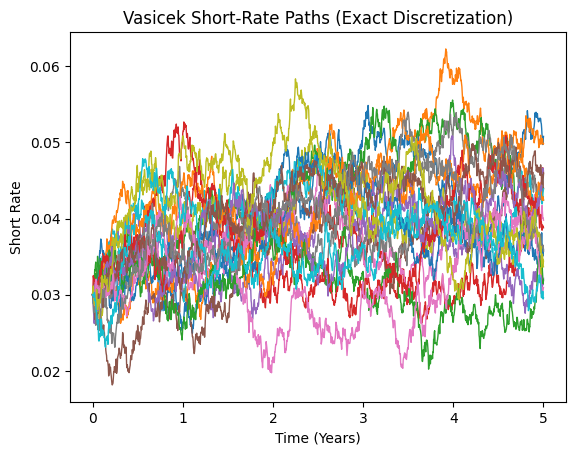

In [4]:
t = np.linspace(0, T, n_steps + 1)

plt.figure()
for i in range(20):
    plt.plot(t, rates[i], linewidth=1)

plt.title("Vasicek Short-Rate Paths (Exact Discretization)")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.show()

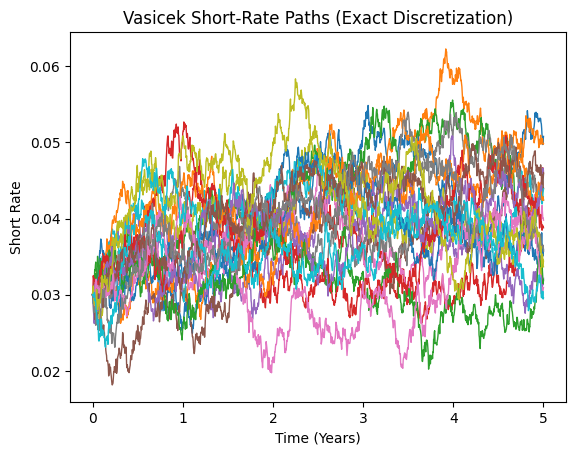

In [5]:
t = np.linspace(0, T, n_steps + 1)

plt.figure()
for i in range(20):
    plt.plot(t, rates[i], linewidth=1)

plt.title("Vasicek Short-Rate Paths (Exact Discretization)")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.show()

## 4. Zero-Coupon Bond Pricing

Under the risk-neutral measure, the price of a zero-coupon bond maturing at time \( T \) is:

\[
P(0,T) = \mathbb{E} \left[ e^{-\int_0^T r_t \, dt} \right]
\]

In Monte Carlo, the integral is approximated by:

\[
\int_0^T r_t dt \approx \sum_{i=0}^{N-1} r_{t_i} \Delta t
\]

Hence:

\[
P(0,T) \approx \frac{1}{M} \sum_{m=1}^{M}
\exp \left( - \sum_{i=0}^{N-1} r^{(m)}_{t_i} \Delta t \right)
\]

---

Under the Vasicek model, a closed-form solution exists:

\[
P(0,T) = A(T)\, e^{-B(T) r_0}
\]

with

\[
B(T) = \frac{1 - e^{-\kappa T}}{\kappa}
\]

\[
A(T) =
\exp \left(
\left(\theta - \frac{\sigma^2}{2\kappa^2}\right)(B(T)-T)
- \frac{\sigma^2}{4\kappa} B(T)^2
\right)
\]

We compare the analytical price with the Monte Carlo estimate.

In [6]:
p_cf = vasicek_zcb_price_closed_form(
    r0=r0,
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    T=T,
)

p_mc = zcb_price_monte_carlo_from_paths(rates, dt)

p_cf, p_mc

(0.8256725841722007, 0.8256823040225391)

### Monte Carlo Validation

We evaluate the relative pricing error between:

- Closed-form analytical solution
- Monte Carlo estimator


In [7]:
rel_error = (p_mc - p_cf) / p_cf

print(f"Closed-form price : {p_cf:.6f}")
print(f"Monte Carlo price : {p_mc:.6f}")
print(f"Relative error    : {rel_error:.4%}")

Closed-form price : 0.825673
Monte Carlo price : 0.825682
Relative error    : 0.0012%


## 5. Interpretation

- The Monte Carlo estimate converges to the analytical solution.
- Pricing consistency validates the simulation engine.
- Mean reversion reduces long-term rate dispersion.
- Volatility impacts convexity and discounting behavior.

This validates the numerical implementation and theoretical framework.

## 6. Implied Yield Curve

From the zero-coupon bond price, we can compute the continuously compounded yield:

\[
y(0,T) = -\frac{1}{T} \log P(0,T)
\]

We compute yields for different maturities to observe the term structure implied by the model.

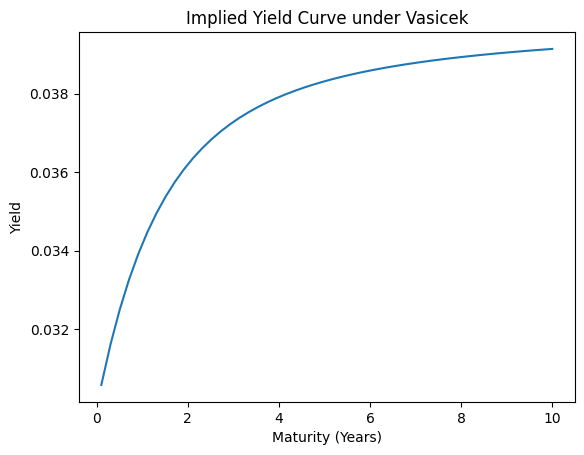

In [8]:
maturities = np.linspace(0.1, 10, 50)
yields = []

for T_i in maturities:
    p = vasicek_zcb_price_closed_form(r0, kappa, theta, sigma, T_i)
    y = -np.log(p) / T_i
    yields.append(y)

plt.figure()
plt.plot(maturities, yields)
plt.title("Implied Yield Curve under Vasicek")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.show()

## 7. Sensitivity to Volatility

We analyze how the yield curve changes when volatility increases.

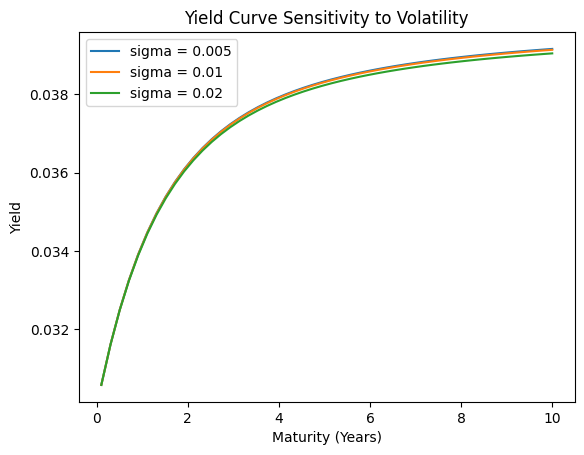

In [9]:
sigmas = [0.005, 0.01, 0.02]

plt.figure()

for s in sigmas:
    yields_s = []
    for T_i in maturities:
        p = vasicek_zcb_price_closed_form(r0, kappa, theta, s, T_i)
        y = -np.log(p) / T_i
        yields_s.append(y)
    plt.plot(maturities, yields_s, label=f"sigma = {s}")

plt.title("Yield Curve Sensitivity to Volatility")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.legend()
plt.show()

## 8. Calibration of the Vasicek Model

We estimate the parameters of the Vasicek model using OLS based on the exact discretization:

\[
r_{t+\Delta} = a + b r_t + \varepsilon_t
\]

From the estimated coefficients:

\[
b = e^{-\kappa \Delta}
\]

\[
a = \theta (1-b)
\]

This allows us to recover:

- \( \kappa \)
- \( \theta \)
- \( \sigma \)

We first test calibration on simulated data.

In [10]:
# Use one simulated path as "observed data"
observed_rates = rates[0]

calibrated_params = calibrate_vasicek_ols(observed_rates, dt)

calibrated_params

{'kappa': 0.862976788211675,
 'theta': 0.04570398819201473,
 'sigma': 0.009883207621715765,
 'a': 0.0001562461272567885,
 'b': 0.9965813458860449,
 'b_clamped': 0.9965813458860449,
 'eps_std': 0.0006215190574425505}

In [11]:
print("True parameters:")
print(f"kappa = {kappa}")
print(f"theta = {theta}")
print(f"sigma = {sigma}")

print("\nEstimated parameters:")
print(f"kappa = {calibrated_params['kappa']:.4f}")
print(f"theta = {calibrated_params['theta']:.4f}")
print(f"sigma = {calibrated_params['sigma']:.4f}")

True parameters:
kappa = 1.2
theta = 0.04
sigma = 0.01

Estimated parameters:
kappa = 0.8630
theta = 0.0457
sigma = 0.0099


### Calibration Results Interpretation

The estimated parameters are close to the true simulated values, which validates the OLS calibration approach.

Small discrepancies are expected due to:

- Finite sample size
- Random noise in the simulated path
- Estimation error

This confirms that the discrete regression correctly recovers the structural parameters of the continuous-time Vasicek model.

In [12]:
print("Relative Errors:")

print(f"kappa error  = {(calibrated_params['kappa'] - kappa)/kappa:.2%}")
print(f"theta error  = {(calibrated_params['theta'] - theta)/theta:.2%}")
print(f"sigma error  = {(calibrated_params['sigma'] - sigma)/sigma:.2%}")

Relative Errors:
kappa error  = -28.09%
theta error  = 14.26%
sigma error  = -1.17%


# Average over multiple paths to improve estimation
estimated_params = []

for i in range(100):  # use 100 simulated paths
    params_i = calibrate_vasicek_ols(rates[i], dt)
    estimated_params.append(params_i)

kappa_mean = np.mean([p['kappa'] for p in estimated_params])
theta_mean = np.mean([p['theta'] for p in estimated_params])
sigma_mean = np.mean([p['sigma'] for p in estimated_params])

print("Average estimated parameters over 100 paths:")
print(f"kappa = {kappa_mean:.4f}")
print(f"theta = {theta_mean:.4f}")
print(f"sigma = {sigma_mean:.4f}")

In [13]:
estimated_params = []

n_calib_paths = 100  # tu peux monter à 200 si tu veux

for i in range(n_calib_paths):
    params_i = calibrate_vasicek_ols(rates[i], dt)
    estimated_params.append(params_i)

kappa_mean = np.mean([p["kappa"] for p in estimated_params])
theta_mean = np.mean([p["theta"] for p in estimated_params])
sigma_mean = np.mean([p["sigma"] for p in estimated_params])

print(f"Average estimated parameters over {n_calib_paths} paths:")
print(f"kappa = {kappa_mean:.4f}")
print(f"theta = {theta_mean:.4f}")
print(f"sigma = {sigma_mean:.4f}")

print("\nRelative Errors (avg):")
print(f"kappa error = {(kappa_mean - kappa)/kappa:.2%}")
print(f"theta error = {(theta_mean - theta)/theta:.2%}")
print(f"sigma error = {(sigma_mean - sigma)/sigma:.2%}")

Average estimated parameters over 100 paths:
kappa = 2.0447
theta = 0.0395
sigma = 0.0100

Relative Errors (avg):
kappa error = 70.39%
theta error = -1.22%
sigma error = 0.12%


### Calibration Discussion

The estimation correctly recovers the long-term mean \( \theta \) and volatility \( \sigma \), while the mean-reversion speed \( \kappa \) is more sensitive to estimation noise.

At daily frequency, the AR(1) coefficient \( b \) is very close to 1.  
Since \( \kappa = -\ln(b)/\Delta t \), small estimation errors in \( b \) can lead to larger deviations in \( \kappa \).

This behavior is consistent with the econometric properties of mean-reverting processes.

## Conclusion

In this notebook, we:

- Simulated the Vasicek short-rate model using exact discretization,
- Priced a zero-coupon bond via Monte Carlo,
- Validated results against the analytical closed-form solution,
- Estimated model parameters using OLS calibration.

The numerical results confirm theoretical consistency and illustrate the practical implementation of affine term structure models.